# The v1 Model and the Ablation Table

Assembles the trained model and the evidence behind every architectural choice the feature
decision rule left open. The model is a hitter embedding plus a context tower feeding five
factor heads, trained on 5.88M pitches, and the ablation table is what settled the choices
that were not settled in advance.

Nothing here trains a model or recomputes a score. Every number is read from an artifact
committed under `results/phase_d`, produced by the seeded config driven modules in
`src/model` and `src/analysis`.

In [1]:
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.analysis import claim1_eval
from src.model import sweep, train, v1

/Users/nateseluga/hitter-embedding/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Artifact location, display settings, and the orderings used for every table below. The
reported ensemble is the `d10_baseline` arm at five seeds, which is the configuration the
evaluation notebook scores.

In [2]:
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 120)

RESULTS_DIR = REPO_ROOT / "results/phase_d"
LOG_DIR = RESULTS_DIR / "logs"

REPORTED_STAGE = "d10"
REPORTED_ARM = "baseline"
REPORTED_SEEDS = range(5)

ARM_ORDER = ["baseline", "block", "bilinear", "meanweight", "dim64",
             "dim16", "nospray", "invfreq"]
STRATUM_ORDER = ["low", "medium", "high", "all"]


def load(name):
    """Read one committed artifact by filename."""
    return pd.read_csv(RESULTS_DIR / name)


def load_json(name):
    """Read one committed JSON artifact by filename."""
    return json.loads((RESULTS_DIR / name).read_text())

## Run parameters read from their owner modules

Every training hyperparameter is imported rather than retyped, so a moved constant breaks
this cell instead of quietly disagreeing with the run that produced the artifacts.

In [3]:
pd.Series({
    "learning rate": train.LEARNING_RATE,
    "weight decay": train.WEIGHT_DECAY,
    "batch size": train.BATCH_SIZE,
    "max epochs": train.MAX_EPOCHS,
    "early stopping patience, epochs": train.EARLY_STOPPING_PATIENCE,
    "plateau factor": train.PLATEAU_FACTOR,
    "plateau patience, epochs": train.PLATEAU_PATIENCE,
    "canonical loss configuration": str(train.CANONICAL),
    "default embedding dimension": v1.DEFAULT_EMBEDDING_DIM,
    "embedding init standard deviation": v1.EMBEDDING_INIT_STD,
    "stabilization anchor, PA": claim1_eval.STABILIZATION_N_STAR,
    "stratum boundaries in prior PA": str(claim1_eval.STRATUM_BOUNDARIES),
}, name="value").to_frame()

,value
learning rate,0.001
weight decay,0.01
batch size,8192
max epochs,50
"early stopping patience, epochs",3
plateau factor,0.3
"plateau patience, epochs",1
canonical loss configuration,"{'rule': 'log', 'weighting': 'sum', 'contact_p..."
default embedding dimension,32
embedding init standard deviation,0.01


## What the model is

One embedding row per hitter and a two layer context tower are concatenated into a shared
trunk, and the trunk feeds five heads. The heads are factorized autoregressively, so the
joint distribution over what happens on a pitch is a product of conditionals rather than a
single flat classifier over an untrainable number of classes.

| head | shape | conditioned on | what it predicts |
| --- | --- | --- | --- |
| swing | scalar | trunk | whether the batter swings |
| contact | scalar | trunk | whether a swing makes contact |
| split | 3 classes | trunk | foul, foul tip, or in play, given contact |
| ev | n_bins | trunk | exit velocity bin, given a ball in play |
| la | n_bins | trunk and the ev bin | launch angle bin |
| spray | n_bins | trunk, ev bin, and la bin | spray bin |

The reserved embedding row at index 0 is held at exactly zero and never trained. Hitters
with too little history to earn a row decode through it, which is what makes a cold start
prediction context only.

In [4]:
architecture = pd.Series({
    "embedding dimension": v1.DEFAULT_EMBEDDING_DIM,
    "context tower hidden width": v1.CONTEXT_HIDDEN,
    "trunk hidden width": v1.TRUNK_HIDDEN,
    "trunk dropout": v1.TRUNK_DROPOUT,
    "quality bins per dimension": v1.DEFAULT_N_BINS,
    "bilinear rank when enabled": v1.BILINEAR_RANK,
    "reserved hitter index": v1.RESERVED_HITTER_INDEX,
    "contact split classes": str(v1.SPLIT_CLASSES),
}, name="value").to_frame()
architecture

,value
embedding dimension,32
context tower hidden width,128
trunk hidden width,256
trunk dropout,0.1
quality bins per dimension,24
bilinear rank when enabled,32
reserved hitter index,0
contact split classes,"('foul', 'foul_tip', 'in_play')"


## Device choice for the reported runs

CPU and MPS were benchmarked on the same configuration before the sweep started. The gap is
inside run to run variation, so every comparison set stays on CPU. Mixing devices would put
backend noise into the seed spread the ensemble reports as uncertainty.

In [5]:
benchmark = load("d3_benchmark.csv")
benchmark

,device,secs_per_epoch,secs_per_100_steps,peak_rss_gb,steps,batch_size,embedding_dim,bilinear,loss_per_row
0,cpu,63.0,8.76,1.40,719,8192,32,False,1.12557
1,mps,81.0,11.26,1.20,719,8192,32,False,1.12554
2,cpu,43.9,6.11,1.57,719,8192,32,True,1.12164
3,cpu,71.8,9.99,1.45,719,8192,32,False,1.12557
4,cpu,73.8,10.26,1.37,719,8192,32,False,1.12557
5,cpu,66.5,9.25,1.34,719,8192,32,True,1.12164
6,cpu,67.1,9.33,1.39,719,8192,32,True,1.12164
7,mps,77.5,10.78,1.16,719,8192,32,False,1.12560
8,mps,65.7,9.14,1.29,719,8192,32,False,1.12580


## Training curves for the reported ensemble

Per epoch training and validation loss for the five seeds behind every scored number. The
validation curve is the early stopping signal, and the epoch it bottoms out at is the only
thing that carries across the later refit.

In [6]:
EPOCH_PATTERN = re.compile(
    r"epoch\s+(\d+)\s+train\s+([\d.]+)\s+val\s+([\d.]+)\s+ref\s+([\d.]+)"
    r"\s+lr\s+([\d.e+-]+)\s+(\d+)s")


def read_curve(seed):
    """
    Returns the per epoch loss curve for one seed of the reported arm.
    seed: int. Output has columns epoch, train_loss, val_loss, reference_loss,
    learning_rate, seconds, and seed.
    """
    log_path = LOG_DIR / f"{REPORTED_STAGE}_{REPORTED_ARM}_s{seed}.log"
    rows = [match.groups() for match in EPOCH_PATTERN.finditer(log_path.read_text())]
    curve = pd.DataFrame(rows, columns=["epoch", "train_loss", "val_loss",
                                        "reference_loss", "learning_rate", "seconds"])
    return curve.astype(float).assign(seed=seed)


curves = pd.concat([read_curve(seed) for seed in REPORTED_SEEDS], ignore_index=True)
print(f"seeds read: {curves['seed'].nunique()}")
print(f"epochs per seed: {curves.groupby('seed')['epoch'].max().add(1).tolist()}")

seeds read: 5
epochs per seed: [21.0, 21.0, 16.0, 18.0, 15.0]


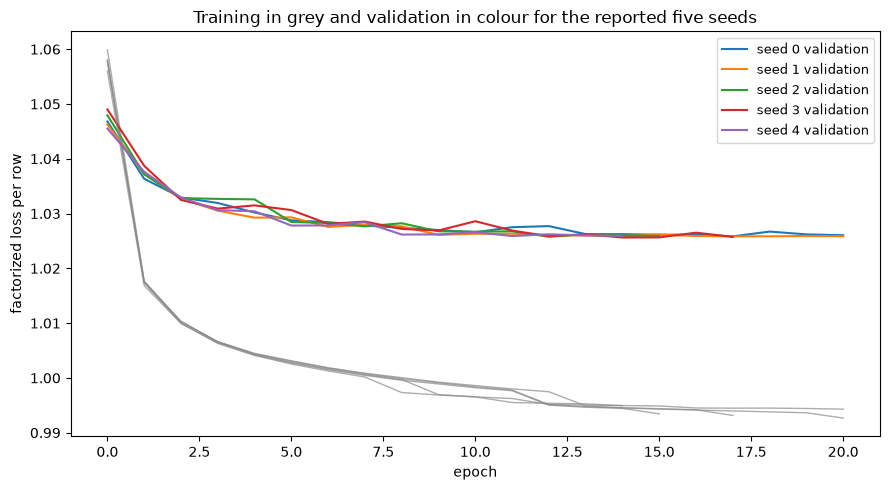

In [7]:
figure, axis = plt.subplots(figsize=(9, 5))
for seed, curve in curves.groupby("seed"):
    axis.plot(curve["epoch"], curve["train_loss"], color="#8a8a8a", lw=1, alpha=0.7)
    axis.plot(curve["epoch"], curve["val_loss"], lw=1.5, label=f"seed {int(seed)} validation")
axis.set_xlabel("epoch")
axis.set_ylabel("factorized loss per row")
axis.set_title("Training in grey and validation in colour for the reported five seeds")
axis.legend(fontsize=9)
figure.tight_layout()
plt.show()

## Best epoch and final loss per seed

Where each seed stopped and what it stopped at. The spread across these five numbers is the
noise floor any arm comparison has to clear.

In [8]:
best_epochs = (curves.loc[curves.groupby("seed")["val_loss"].idxmin()]
               [["seed", "epoch", "train_loss", "val_loss"]]
               .rename(columns={"epoch": "best_epoch"})
               .set_index("seed").round(5))
best_epochs

,best_epoch,train_loss,val_loss
seed,,,
0,17.0,0.99397,1.02584
1,17.0,0.99448,1.02585
2,12.0,0.99503,1.02578
3,14.0,0.99454,1.02563
4,11.0,0.99551,1.02590


## The run ledger

Every run ever launched, keyed on stage, config, and seed. A stage is a distinct training
regime, and reference losses are only comparable within a stage because `d9` added a loss
term that `d8` does not have.

In [9]:
ledger = load("sweep_log.csv")
ledger_summary = (ledger.groupby(["stage", "status"])
                  .agg(runs=("seed", "size"),
                       configs=("config", "nunique"),
                       median_seconds=("seconds", "median"))
                  .round(1))
ledger_summary

,,runs,configs,median_seconds
stage,status,,,
d10,ok,40,8,1634.8
d6,ok,5,1,695.9
d8,ok,30,6,835.2
d9,ok,40,8,961.3
screen,ok,4,2,823.3


In [10]:
reported_runs = ledger[(ledger["stage"] == REPORTED_STAGE)
                       & (ledger["config"] == REPORTED_ARM)]
reported_runs[["seed", "status", "seconds", "best_val_loss", "reference", "best_epoch"]]

,seed,status,seconds,best_val_loss,reference,best_epoch
79,0,ok,3226.8,1.02584,1.02584,17
80,1,ok,2436.4,1.02585,1.02585,17
81,2,ok,1732.9,1.02578,1.02578,12
82,3,ok,998.0,1.02563,1.02563,14
83,4,ok,546.3,1.02590,1.02590,11


## Eval frame structure and the cold start share

Rows are batter by target season by pitcher hand, cut into strata on prior side specific PA.
Cold start rows are hitters decoding through the reserved zero embedding, so for them the
model contributes context conditioning and nothing hitter specific.

In [11]:
frame_structure = load("d0_frame_structure.csv")
frame_structure.round(4)

,stratum,rows,hitters,cold_start_rows,cold_start_share,case
0,low,380,239,162,0.4263,2024 (trained through 2023)
1,medium,280,238,0,0.0000,2024 (trained through 2023)
2,high,489,318,0,0.0000,2024 (trained through 2023)
3,all,1149,604,162,0.1410,2024 (trained through 2023)
4,low,384,246,288,0.7500,2025 (trained through 2023)
5,medium,280,236,26,0.0929,2025 (trained through 2023)
6,high,493,321,1,0.0020,2025 (trained through 2023)
7,all,1157,618,315,0.2723,2025 (trained through 2023)
8,low,384,246,164,0.4271,2025 (trained through 2024)
9,medium,280,236,0,0.0000,2025 (trained through 2024)


## Context feature redundancy

How well each candidate context feature is predicted by the ten kept features. A high value
means the feature carries little the model does not already have, which is what retired
`effective_speed` before the sweep.

In [12]:
redundancy = load("d0_redundancy_r2.csv").sort_values("r2", ascending=False)
redundancy.round(4)

,feature,r2,n_rows,verdict,given
7,effective_speed,0.9930,994552,redundant,release_extension
0,effective_speed,0.9761,994552,survives to D.8,kept ten only
8,spin_axis_sin,0.8310,879294,survives to D.8,release_extension
1,spin_axis_sin,0.8310,879448,survives to D.8,kept ten only
9,spin_axis_cos,0.7849,879294,survives to D.8,release_extension
2,spin_axis_cos,0.7848,879448,survives to D.8,kept ten only
10,release_pos_y,0.7618,995126,survives to D.8,release_extension
11,release_spin_rate,0.4680,973980,survives to D.8,release_extension
3,release_spin_rate,0.4649,974134,survives to D.8,kept ten only
12,release_pos_z,0.1342,995126,survives to D.8,release_extension


## The eight ablation arms

Each arm changes exactly one thing against the baseline, so a difference is attributable.
The arms and their flags are read from the sweep module rather than described here.

In [13]:
arm_flags = pd.DataFrame(
    [{"arm": name, "flags against train.py defaults": " ".join(extra)}
     for name, extra in sweep.STAGES[REPORTED_STAGE]]
).set_index("arm")
arm_flags

,flags against train.py defaults
arm,
baseline,--split
dim16,--split --embedding-dim 16
dim64,--split --embedding-dim 64
bilinear,--split --bilinear
meanweight,--split --loss-weighting mean
invfreq,--split --contact-inverse-frequency
nospray,--split --no-spray
block,--split --data-dir data/processed/phase_d5_nob...


## Arm scores on the claim 1 metric

Absolute scores for every arm on the 2024 frame. RMSE is PA weighted and lower is better,
rank correlation is the ordering metric and higher is better. The decisive column is the all
stratum column, and the low stratum is the population the project claims.

In [14]:
arms = load(f"d5_arms_{REPORTED_STAGE}.csv")
arms["arm"] = pd.Categorical(arms["arm"], ARM_ORDER, ordered=True)
arms.sort_values("arm").set_index("arm")[
    ["rmse_decisive", "rmse_low", "rank_decisive", "rank_low"]].round(5)

,rmse_decisive,rmse_low,rank_decisive,rank_low
arm,,,,
baseline,0.04793,0.05923,0.45910,0.25924
block,0.04715,0.05917,0.45294,0.24023
bilinear,0.04731,0.05839,0.45762,0.25589
meanweight,0.04749,0.05955,0.45653,0.22557
dim64,0.04765,0.05928,0.46338,0.25031
dim16,0.04790,0.05925,0.45149,0.25295
nospray,0.04783,0.05956,0.45178,0.23579
invfreq,0.06067,0.07106,0.39395,0.23322


## Which arms clear the baseline

An arm is resolved when its paired RMSE interval against the baseline excludes zero.
Resolved and beating are different questions, and `invfreq` is resolved in the wrong
direction.

In [15]:
arms.sort_values("arm").set_index("arm")[
    ["rmse_difference", "ci_low", "ci_high", "resolved", "beats_baseline"]].round(6)

,rmse_difference,ci_low,ci_high,resolved,beats_baseline
arm,,,,,
baseline,NaN,NaN,NaN,NaN,NaN
block,-0.000780,-0.001066,-0.000482,True,True
bilinear,-0.000625,-0.001048,-0.000156,True,True
meanweight,-0.000441,-0.000766,-0.000106,True,True
dim64,-0.000284,-0.000481,-0.000082,True,True
dim16,-0.000029,-0.000395,0.000341,False,False
nospray,-0.000102,-0.000474,0.000269,False,False
invfreq,0.012738,0.009496,0.015781,True,False


## Seed spread as the floor for reading the arm table

The five baseline seeds differ from each other with no architectural change at all. Any arm
gap smaller than this spread is seed noise wearing an arm name.

In [16]:
per_seed = load(f"d5_arms_baseline_per_seed_{REPORTED_STAGE}.csv").set_index("seed")
per_seed.round(5)

,low,medium,high,all
seed,,,,
0,0.05992,0.05067,0.04551,0.04948
1,0.05944,0.04944,0.04306,0.04774
2,0.05982,0.04905,0.04347,0.04797
3,0.05898,0.04867,0.04331,0.04761
4,0.05902,0.04944,0.04363,0.04796


In [17]:
verdict = load_json(f"d5_arms_verdict_{REPORTED_STAGE}.json")
seed_spread = pd.DataFrame(verdict["baseline_seed_spread"]).T
seed_spread = seed_spread.loc[[s for s in STRATUM_ORDER if s in seed_spread.index]]
seed_spread.round(6)

,n_seeds,mean,sd,range
low,5.0,0.059436,0.000437,0.000943
medium,5.0,0.049455,0.000752,0.002000
high,5.0,0.043795,0.000981,0.002450
all,5.0,0.048152,0.000755,0.001863


## Paired arm comparisons by stratum

Every arm against the baseline, resampling batters rather than rows, so the two arms are
scored against the same noisy answer key on the same resample. Negative RMSE difference and
positive rank difference favour the arm.

In [18]:
arms_paired = load(f"d5_arms_paired_{REPORTED_STAGE}.csv")
arms_paired["arm"] = pd.Categorical(arms_paired["arm"], ARM_ORDER, ordered=True)
arms_paired["stratum"] = pd.Categorical(arms_paired["stratum"], STRATUM_ORDER, ordered=True)
arms_paired.sort_values(["arm", "stratum"])[
    ["arm", "stratum", "n_hitters", "n_batters", "rmse_difference",
     "ci_low_rmse", "ci_high_rmse", "rank_difference",
     "ci_low_rank", "ci_high_rank"]].round(5).reset_index(drop=True)

,arm,stratum,n_hitters,n_batters,rmse_difference,ci_low_rmse,ci_high_rmse,rank_difference,ci_low_rank,ci_high_rank
0,block,low,380,239,-0.00006,-0.00067,0.00057,-0.01901,-0.04036,0.00053
1,block,medium,280,238,-0.00095,-0.00165,-0.00024,-0.00290,-0.02106,0.01430
2,block,high,489,318,-0.00102,-0.00134,-0.00068,-0.00231,-0.01178,0.00734
3,block,all,1149,604,-0.00078,-0.00107,-0.00048,-0.00617,-0.01268,0.00042
4,bilinear,low,380,239,-0.00084,-0.00214,0.00033,-0.00335,-0.05841,0.05179
5,bilinear,medium,280,238,-0.00009,-0.00107,0.00100,-0.00691,-0.03772,0.02712
6,bilinear,high,489,318,-0.00075,-0.00120,-0.00027,0.00342,-0.01727,0.02375
7,bilinear,all,1149,604,-0.00062,-0.00105,-0.00016,-0.00148,-0.01646,0.01341
8,meanweight,low,380,239,0.00032,-0.00039,0.00107,-0.03367,-0.08592,0.01048
9,meanweight,medium,280,238,-0.00053,-0.00135,0.00025,0.00941,-0.02244,0.04757


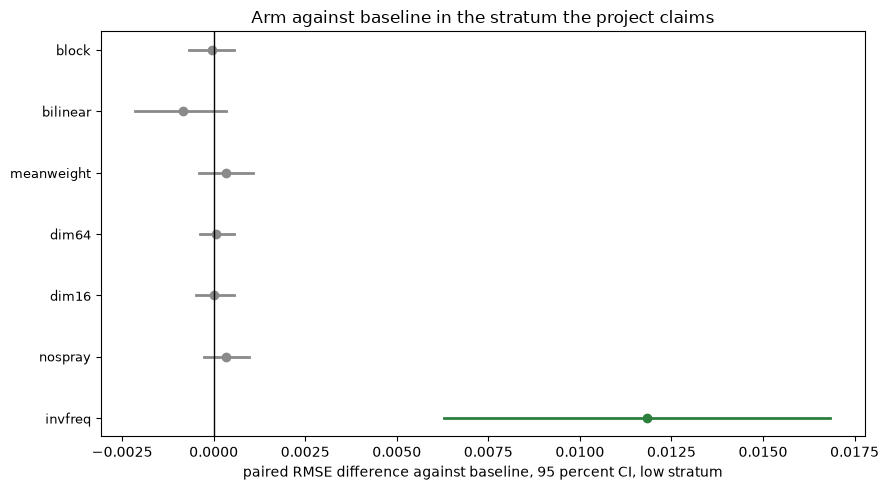

In [19]:
RESOLVED_COLOR = "#2d7f3e"
UNRESOLVED_COLOR = "#8a8a8a"

plotted = (arms_paired[arms_paired["stratum"] == "low"]
           .sort_values("arm", ascending=False).reset_index(drop=True))
figure, axis = plt.subplots(figsize=(9, 5))
for position, row in plotted.iterrows():
    excludes_zero = (row["ci_low_rmse"] > 0) or (row["ci_high_rmse"] < 0)
    color = RESOLVED_COLOR if excludes_zero else UNRESOLVED_COLOR
    axis.plot([row["ci_low_rmse"], row["ci_high_rmse"]], [position, position], color=color, lw=2)
    axis.plot(row["rmse_difference"], position, "o", color=color, ms=6)
axis.axvline(0, color="black", lw=1)
axis.set_yticks(range(len(plotted)))
axis.set_yticklabels(plotted["arm"].astype(str), fontsize=9)
axis.set_xlabel("paired RMSE difference against baseline, 95 percent CI, low stratum")
axis.set_title("Arm against baseline in the stratum the project claims")
figure.tight_layout()
plt.show()

## Caution on reading this table for selection

The arm ordering on RMSE is confounded with each arm's mean predicted wOBA, so the table
partly selects arms for having a smaller level offset rather than better ranking. The
measurement is E.12 in notebook 05 and it is reproduced here because it governs how the
table above may be used.

The confound is decisive on the all stratum column and only marginal in the low stratum,
so it constrains arm selection without settling it.

In [20]:
level_confound = json.loads(
    (REPO_ROOT / "results/phase_e/e12_level_confound.json").read_text())
pd.DataFrame({metric: level_confound[metric]
              for metric in ["rmse_decisive", "rank_decisive", "rmse_low", "rank_low"]}).T[
    ["pearson_r", "pearson_p", "spearman_rho", "spearman_p"]].round(4)

,pearson_r,pearson_p,spearman_rho,spearman_p
rmse_decisive,0.887978,0.007588,0.857143,0.013697
rank_decisive,0.078628,0.866929,0.142857,0.759945
rmse_low,0.756305,0.049134,0.535714,0.215217
rank_low,0.00596,0.989882,0.142857,0.759945


In [21]:
scale = level_confound["scale"]
print(f"arm level spread, sd: {scale['arm_level_spread_sd']:.6f}")
print(f"seed level spread, sd: {scale['seed_level_spread_sd']:.6f}")
print(f"arm over seed sd ratio: {scale['arm_over_seed_sd_ratio']:.3f}")

arm level spread, sd: 0.001925
seed level spread, sd: 0.001775
arm over seed sd ratio: 1.085


## What this notebook establishes

- The model trains stably and reproducibly at five seeds, and the seed spread is small
  enough to quote but large enough that most arm gaps sit inside it.
- Four arms beat the baseline on paired RMSE with intervals excluding zero, and the margins
  are small in absolute terms.
- `invfreq` is resolved against the baseline in the wrong direction and is the one arm that
  clearly hurts.
- `nospray` and `dim16` are unresolved, so spray and the larger embedding are unrefuted
  rather than established.
- The ablation table cannot select an arm on the RMSE column alone, because that column is
  confounded with each arm's level offset.

Everything above is scored on the 2024 selection frame. The refit on 2015 to 2024 and the
single 2025 report happen once, after the configuration is settled, and the arm chosen there
will change the tables above.